In [2]:
import pandas as pd
df_sci = pd.read_csv('science/Combined MPRA Summary Stats.csv',index_col=0)
df_zc = pd.read_csv('../ad_mpra_chen/outputs/allele_effects_for_plotting/annotated_20240719_comparative_HEK293T_alleleOnly.csv' ,index_col=0)[['rsid','Major','Minor','fdr','logFC_converted','center']]

df_zc['seq_id'] = df_zc.index

df_haploreg = pd.read_csv('indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_MAFCorrect_REFindex_catlas_with_all_peakfiles_20260112.csv',index_col=0)
df_zc = pd.merge(df_zc,df_haploreg[['GC_content',	'distance_to_tss',	'SNP_Function']],left_index=True,right_index=True)
df_overlap = df_zc[df_zc['rsid'].isin(df_sci.index)]


In [3]:
df_overlap

,rsid,Major,Minor,fdr,logFC_converted,center,seq_id,GC_content,distance_to_tss,SNP_Function
alt:rs1004173:PEAKCENTER:chr6:47445017:C:T:47444925:47446243:47444993,rs1004173,C,T,0.001764,-0.126171,PEAKCENTER,alt:rs1004173:PEAKCENTER:chr6:47445017:C:T:474...,40.088106,508,Low ATAC
alt:rs1004173:PEAKCENTER:chr6:47445017:C:T:47445015:47446766:47445073,rs1004173,C,T,0.029679,0.082186,PEAKCENTER,alt:rs1004173:PEAKCENTER:chr6:47445017:C:T:474...,49.779736,508,Low ATAC
alt:rs10414043:SNPCENTER:chr19:44912456:G:A:44912343:44912569:44912456,rs10414043,G,A,0.122040,-0.062158,SNPCENTER,alt:rs10414043:SNPCENTER:chr19:44912456:G:A:44...,50.220264,1791,Low ATAC
alt:rs10736700:PEAKCENTER:chr11:60031399:T:C:60030928:60031502:60031453,rs10736700,C,T,0.000031,-0.206160,PEAKCENTER,alt:rs10736700:PEAKCENTER:chr11:60031399:T:C:6...,45.814978,-20789,Low ATAC
alt:rs10736701:PEAKCENTER:chr11:60031476:C:T:60030928:60031502:60031453,rs10736701,T,C,0.440689,-0.038133,PEAKCENTER,alt:rs10736701:PEAKCENTER:chr11:60031476:C:T:6...,44.933921,-20866,Low ATAC
...,...,...,...,...,...,...,...,...,...,...
alt:rs9304646:PEAKCENTER:chr19:44947151:T:A:44946977:44947477:44947227,rs9304646,T,A,0.024609,0.077224,PEAKCENTER,alt:rs9304646:PEAKCENTER:chr19:44947151:T:A:44...,48.017621,-1116,Low ATAC
alt:rs9304646:PEAKCENTER:chr19:44947151:T:C:44946977:44947477:44947227,rs9304646,T,C,0.965279,-0.002200,PEAKCENTER,alt:rs9304646:PEAKCENTER:chr19:44947151:T:C:44...,48.458150,-1116,Low ATAC
alt:rs9304646:PEAKCENTER:chr19:44947151:T:G:44946977:44947477:44947227,rs9304646,T,G,0.048122,0.069436,PEAKCENTER,alt:rs9304646:PEAKCENTER:chr19:44947151:T:G:44...,48.458150,-1116,Low ATAC
alt:rs9357546:PEAKCENTER:chr6:47549495:C:T:47549371:47549664:47549511,rs9357546,C,T,0.000395,-0.166834,PEAKCENTER,alt:rs9357546:PEAKCENTER:chr6:47549495:C:T:475...,39.207048,-19137,Low ATAC


In [4]:
df_overlap_10kbmore = df_overlap[abs(df_overlap['distance_to_tss'])>10000]

In [5]:
# Find the rows in df1 where index matches df2's rsid, A1 matches Major, and A2 matches Minor
df1 = df_sci.reset_index()
df2 = df_overlap
merged_df_allelematch = pd.merge(df1, df2, left_on=['rsID', 'A0', 'A1'], right_on=['rsid', 'Major', 'Minor'])
merged_df_allelereverse = pd.merge(df1, df2, left_on=['rsID', 'A1', 'A0'], right_on=['rsid', 'Major', 'Minor'])
merged_df_allelereverse['Log2.FC']= - merged_df_allelereverse['Log2.FC']
merged_df = pd.concat([merged_df_allelematch,merged_df_allelereverse])
merged_df.set_index('seq_id',inplace=True)

In [6]:
merged_df

,rsID,Disorder,Locus ID,chr,pos,A0,A1,ref,alt,Log2.FC,...,q,rsid,Major,Minor,fdr,logFC_converted,center,GC_content,distance_to_tss,SNP_Function
seq_id,,,,,,,,,,,,,,,,,,,,,
alt:rs7920721:PEAKCENTER:chr10:11720308:A:G:11720219:11720390:11720304,rs7920721,AD,5,chr10,11720308,A,G,1.042396,1.690000,0.650000,...,1.760000e-10,rs7920721,A,G,8.688095e-01,-0.010729,PEAKCENTER,43.171806,1366,Immune
alt:rs580817:PEAKCENTER:chr11:59869090:A:G:59868873:59869373:59869123,rs580817,AD,7,chr11,59869090,A,G,-0.092329,-0.089266,0.003064,...,8.523192e-01,rs580817,A,G,1.301721e-02,0.100220,PEAKCENTER,46.255507,-13356,Low ATAC
alt:rs983392:PEAKCENTER:chr11:59923508:A:G:59923333:59923833:59923583,rs983392,AD,7,chr11,59923508,A,G,-0.813155,-0.756275,0.056880,...,8.672527e-01,rs983392,A,G,4.598043e-02,0.101050,PEAKCENTER,35.682819,4787,Low ATAC
alt:rs107903:PEAKCENTER:chr11:59926256:C:T:59926070:59926570:59926320,rs107903,AD,7,chr11,59926256,C,T,-0.284079,-0.296347,-0.012267,...,7.285331e-01,rs107903,C,T,8.203664e-02,0.095529,PEAKCENTER,38.766520,2039,Low ATAC
alt:rs17529983:PEAKCENTER:chr11:59927039:G:A:59926852:59927051:59926966,rs17529983,AD,7,chr11,59927039,G,A,-0.973952,-1.334773,-0.360821,...,1.523775e-01,rs17529983,G,A,5.814216e-03,0.096105,PEAKCENTER,41.409692,1256,Low ATAC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
alt:rs12539172:PEAKCENTER:chr7:100091795:T:C:100091083:100091870:100091810,rs12539172,AD,30,chr7,100091795,T,C,1.071269,1.012528,0.058741,...,8.307225e-01,rs12539172,C,T,2.859235e-10,-0.247975,PEAKCENTER,59.911894,-10245,Low ATAC
alt:rs1532278:PEAKCENTER:chr8:27466315:T:C:27466212:27466696:27466376,rs1532278,AD,32b,chr8,27466315,T,C,0.097423,-0.102429,0.199852,...,4.525815e-01,rs1532278,C,T,1.835802e-01,-0.123233,PEAKCENTER,58.590308,1953,Low ATAC
alt:rs2070926:PEAKCENTER:chr8:27467821:C:G:27467630:27468130:27467880,rs2070926,AD,32b,chr8,27467821,C,G,-0.453085,-0.474401,0.021316,...,9.858311e-01,rs2070926,G,C,5.240839e-01,-0.026831,PEAKCENTER,57.268722,447,Low ATAC


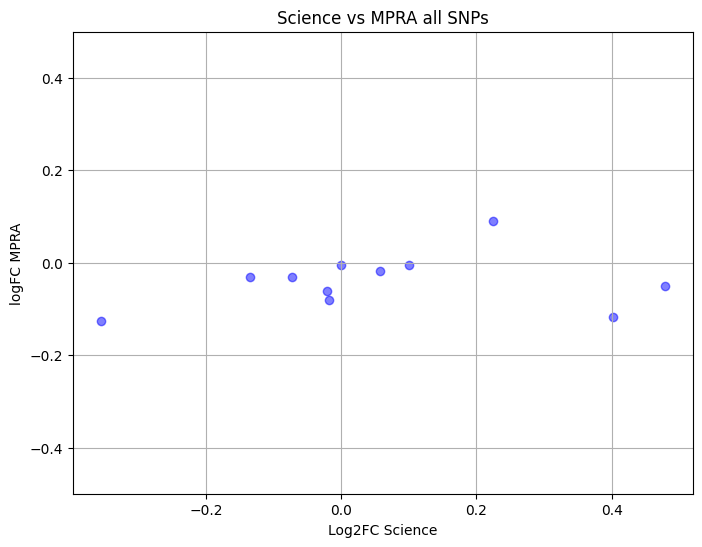

Spearman Correlation Coefficient: 0.30000000000000004
P-value: 0.37008312228206786


In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr
df = merged_df[abs(merged_df['Log2.FC'])<0.8]
df=df[df['center']=='SNPCENTER']
# Creating the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(df['Log2.FC'],df['logFC_converted'], color='blue', alpha=0.5)
plt.title('Science vs MPRA all SNPs')
plt.xlabel('Log2FC Science')
plt.ylabel('logFC MPRA')
plt.grid(True)
plt.ylim(-0.5,0.5)
plt.show()

# Calculate Spearman correlation
correlation, p_value = spearmanr(df['Log2.FC'], df['logFC_converted'])
print("Spearman Correlation Coefficient:", correlation)
print("P-value:", p_value)


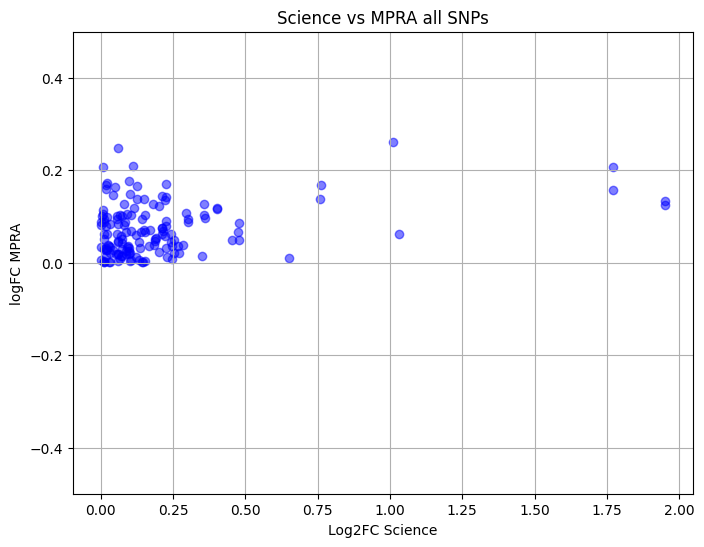

Spearman Correlation Coefficient: 0.17840547582897487 0.031203527031468777
Pearson Correlation Coefficient: 0.31728667911329783 9.534093567650433e-05


In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr,pearsonr
df = merged_df#[abs(merged_df['Log2.FC'])<0.5]
#df=df[df['center']=='PEAKCENTER']
# Creating the scatter plot
plt.figure(figsize=(8, 6))
x,y=abs(df['Log2.FC']),abs(df['logFC_converted'])
plt.scatter(x,y, color='blue', alpha=0.5)
plt.title('Science vs MPRA all SNPs')
plt.xlabel('Log2FC Science')
plt.ylabel('logFC MPRA')
plt.grid(True)
plt.ylim(-0.5,0.5)
plt.show()

# Calculate Spearman correlation
correlation, p_value = spearmanr(x, y)
print("Spearman Correlation Coefficient:", correlation,p_value)
correlation, p_value = pearsonr(x, y)
print("Pearson Correlation Coefficient:", correlation,p_value)


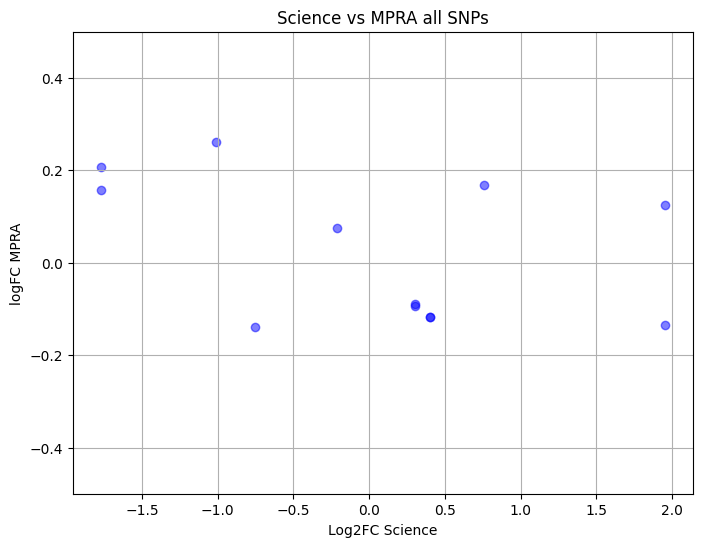

Spearman Correlation Coefficient: -0.3943759765142393
P-value: 0.20458190665795498


In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr
df=merged_df[(merged_df['fdr']<=0.05)&(merged_df['q']<=0.05)]
# Creating the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(df['Log2.FC'],df['logFC_converted'], color='blue', alpha=0.5)
plt.title('Science vs MPRA all SNPs')
plt.xlabel('Log2FC Science')
plt.ylabel('logFC MPRA')
plt.grid(True)
plt.ylim(-0.5,0.5)
plt.show()

# Calculate Spearman correlation
correlation, p_value = spearmanr(df['Log2.FC'], df['logFC_converted'])
print("Spearman Correlation Coefficient:", correlation)
print("P-value:", p_value)


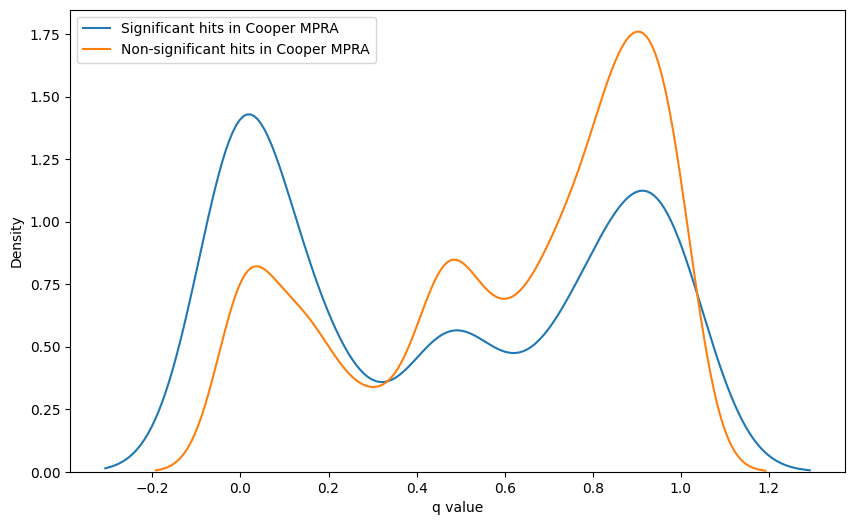

Mann-Whitney U test result:
U-statistic: 1300.0
p-value: 0.05207969357675134
There is no significant difference between the distributions.


In [66]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
data1 = merged_df[merged_df['fdr']<=0.01]['q']
data2 = merged_df[merged_df['fdr']>0.01]['q']
# Create the density plot
plt.figure(figsize=(10, 6))
sns.kdeplot(data1, label='Significant hits in Cooper MPRA', bw_adjust=0.5)
sns.kdeplot(data2, label='Non-significant hits in Cooper MPRA', bw_adjust=0.5)

# Add legend
plt.legend()

# Show plot
plt.xlabel('q value')
plt.ylabel('Density')
#plt.title('Density Plot of Two Series')
plt.show()

# Perform the Mann-Whitney U test
result = stats.mannwhitneyu(data1, data2, alternative='two-sided')

# Print the test results
print("Mann-Whitney U test result:")
print("U-statistic:", result.statistic)
print("p-value:", result.pvalue)

# Interpretation
if result.pvalue < 0.05:
    print("The difference between the distributions is statistically significant.")
else:
    print("There is no significant difference between the distributions.")

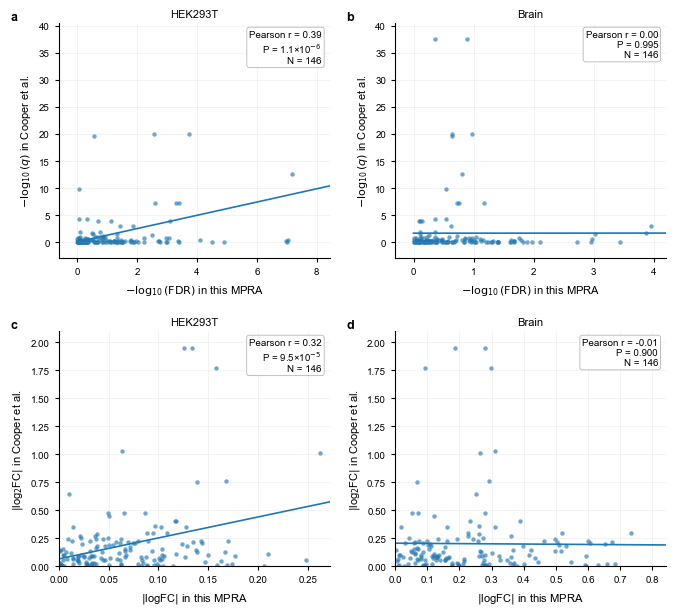

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# =========================
# Global plotting settings
# =========================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================
# Helper functions
# =========================
def fmt_p(p):
    if p < 1e-99:
        return "P < 1×10$^{-99}$"
    elif p < 1e-3:
        base, exp = f"{p:.1e}".split("e")
        return f"P = {float(base):.1f}×10$^{{{int(exp)}}}$"
    else:
        return f"P = {p:.3f}"

def load_zc_context(zc_path, haploreg_path):
    df_zc = pd.read_csv(zc_path, index_col=0)[
        ['rsid', 'Major', 'Minor', 'fdr', 'logFC_converted', 'center']
    ].copy()
    df_zc['seq_id'] = df_zc.index

    df_haploreg = pd.read_csv(haploreg_path, index_col=0)
    df_zc = pd.merge(
        df_zc,
        df_haploreg[['GC_content', 'distance_to_tss', 'SNP_Function']],
        left_index=True,
        right_index=True,
        how='left'
    )
    return df_zc

def merge_with_cooper(df_zc, df_sci):
    df_overlap = df_zc[df_zc['rsid'].isin(df_sci.index)].copy()

    df1 = df_sci.reset_index().copy()
    df2 = df_overlap.copy()

    merged_match = pd.merge(
        df1, df2,
        left_on=['rsID', 'A0', 'A1'],
        right_on=['rsid', 'Major', 'Minor'],
        how='inner'
    )

    merged_rev = pd.merge(
        df1, df2,
        left_on=['rsID', 'A1', 'A0'],
        right_on=['rsid', 'Major', 'Minor'],
        how='inner'
    )
    merged_rev['Log2.FC'] = -merged_rev['Log2.FC']

    merged_df = pd.concat([merged_match, merged_rev], axis=0)
    merged_df = merged_df.drop_duplicates(subset=['seq_id'])
    merged_df = merged_df.set_index('seq_id')
    return merged_df

def style_axes(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linewidth=0.4, alpha=0.25)
    ax.tick_params(width=0.8, length=3)

def add_stats_box(ax, x, y):
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    r, p_r = pearsonr(x, y)

    X = x.reshape(-1, 1)
    model = LinearRegression().fit(X, y)
    slope = float(model.coef_[0])
    intercept = float(model.intercept_)
    y_hat = model.predict(X)
    r2 = r2_score(y, y_hat)

    text = (
        f"Pearson r = {r:.2f}\n"
        f"{fmt_p(p_r)}\n"
       # f"$R^2$ = {r2:.2f}\n"
        f"N = {len(x)}"
    )

    ax.text(
        0.97, 0.97, text,
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=7,
        bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='0.7', lw=0.6, alpha=0.95)
    )

    return slope, intercept

def robust_limits(vals, lower_q=0.0, upper_q=0.995, pad_frac=0.06, min_span=1.0):
    vals = np.asarray(vals)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return 0, 1

    lo = np.quantile(vals, lower_q)
    hi = np.quantile(vals, upper_q)

    if hi <= lo:
        hi = lo + min_span

    pad = max((hi - lo) * pad_frac, min_span * 0.02)
    return lo - pad, hi + pad

def plot_sig_panel(ax, merged_df, panel_label, context_label):
    eps = 1e-300
    x = -np.log10(np.clip(merged_df["fdr"].to_numpy(dtype=float), eps, 1.0))
    y = -np.log10(np.clip(merged_df["q"].to_numpy(dtype=float), eps, 1.0))

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    ax.scatter(x, y, s=10, alpha=0.65, linewidth=0)

    slope, intercept = add_stats_box(ax, x, y)

    xmin, xmax = robust_limits(x, lower_q=0.0, upper_q=0.995, pad_frac=0.08, min_span=1.0)
    ymin, ymax = robust_limits(y, lower_q=0.0, upper_q=0.995, pad_frac=0.08, min_span=1.0)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    xx = np.linspace(max(0, xmin), xmax, 200)
    ax.plot(xx, slope * xx + intercept, linewidth=1.2)

    ax.set_xlabel(r"$-\log_{10}(\mathrm{FDR})$ in this MPRA")
    ax.set_ylabel(r"$-\log_{10}(q)$ in Cooper et al.")
    ax.set_title(context_label, pad=4)

    ax.text(
        -0.18, 1.05, panel_label,
        transform=ax.transAxes,
        fontsize=9, fontweight='bold',
        va='top', ha='left'
    )

    style_axes(ax)

def plot_effect_panel(ax, merged_df, panel_label, context_label):
    x = np.abs(merged_df["logFC_converted"].to_numpy(dtype=float))
    y = np.abs(merged_df["Log2.FC"].to_numpy(dtype=float))

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    ax.scatter(x, y, s=10, alpha=0.65, linewidth=0)

    slope, intercept = add_stats_box(ax, x, y)

    xmin, xmax = robust_limits(x, lower_q=0.0, upper_q=0.995, pad_frac=0.08, min_span=0.2)
    ymin, ymax = robust_limits(y, lower_q=0.0, upper_q=0.995, pad_frac=0.08, min_span=0.2)

    xmin = max(0, xmin)
    ymin = max(0, ymin)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    xx = np.linspace(xmin, xmax, 200)
    ax.plot(xx, slope * xx + intercept, linewidth=1.2)

    ax.set_xlabel(r"$|$logFC$|$ in this MPRA")
    ax.set_ylabel(r"$|$log$_2$FC$|$ in Cooper et al.")
    ax.set_title(context_label, pad=4)

    ax.text(
        -0.18, 1.05, panel_label,
        transform=ax.transAxes,
        fontsize=9, fontweight='bold',
        va='top', ha='left'
    )

    style_axes(ax)

# =========================
# Load data
# =========================
df_sci = pd.read_csv('science/Combined MPRA Summary Stats.csv', index_col=0)

haploreg_path = 'indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_MAFCorrect_REFindex_catlas_with_all_peakfiles_20260112.csv'

hek_path = '../ad_mpra_chen/outputs/allele_effects_for_plotting/annotated_20240719_comparative_HEK293T_alleleOnly.csv'
brain_path = '../ad_mpra_chen/outputs/allele_effects_for_plotting/annotated_20240616_comparative_BrainR1R2merged20240404_alleleOnly.csv'

df_hek = load_zc_context(hek_path, haploreg_path)
df_brain = load_zc_context(brain_path, haploreg_path)

merged_hek = merge_with_cooper(df_hek, df_sci)
merged_brain = merge_with_cooper(df_brain, df_sci)

# =========================
# Plot 2x2 figure
# =========================
fig, axes = plt.subplots(2, 2, figsize=(6.8, 6.2))

plot_sig_panel(axes[0, 0], merged_hek, "a", "HEK293T")
plot_sig_panel(axes[0, 1], merged_brain, "b", "Brain")
plot_effect_panel(axes[1, 0], merged_hek, "c", "HEK293T")
plot_effect_panel(axes[1, 1], merged_brain, "d", "Brain")

plt.tight_layout(w_pad=1.5, h_pad=1.8)

# only save PNG
plt.savefig("Cooper_comparison_4panel.png", dpi=600, bbox_inches="tight")
plt.show()